## Import 

In [5]:
import os 
import json 
import shutil
from pathlib import Path
from collections import defaultdict 
from PIL import Image
import random
import matplotlib.pyplot as plt 
import numpy as np 
import matplotlib.patches as patches


from ultralytics import YOLO
import torch

## constant

In [1]:
BASE = '../CarDD_release/CarDD_COCO'
OUTPUT_BASE = '/CarDD_YOLO_SEG'

SPLITS = {
    'train' : f'{BASE}/annotations/instances_train2017.json',
    'val'   : f'{BASE}/annotations/instances_val2017.json',
    'test'  : f'{BASE}/annotations/instances_test2017.json',
}

IMG_DIRS = {
    'train' : f'{BASE}/train2017',
    'val'   : f'{BASE}/val2017',
    'test'  : f'{BASE}/test2017',
}

CLASSES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
COLORS  = [
    [76,  114, 176],   # blue   - dent
    [221, 132,  82],   # orange - scratch
    [85,  168, 104],   # green  - crack
    [196,  78,  82],   # red    - glass shatter
    [129, 114, 178],   # purple - lamp broken
    [147, 120,  96],   # brown  - tire flat
]

## Prepare the data 

In [4]:
for split in SPLITS:
    Path(f'{OUTPUT_BASE}/images/{split}').mkdir(parents=True, exist_ok=True)
    Path(f'{OUTPUT_BASE}/labels/{split}').mkdir(parents=True, exist_ok=True)

In [5]:
def coco_to_yolo_seg(json_path, split):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img_lookup = {img['id']: img for img in data['images']}
    anns_by_image = defaultdict(list)
    for ann in data['annotations']:
        anns_by_image[ann['image_id']].append(ann)
    converted = 0
    skipped   = 0

    for img_id, img_info in img_lookup.items():
        w     = img_info['width']
        h     = img_info['height']
        fname = img_info['file_name']
        src = os.path.join(IMG_DIRS[split], fname)
        dst = os.path.join(OUTPUT_BASE, 'images', split, fname)
        if not os.path.exists(dst):
            os.symlink(src, dst)
        label_path = os.path.join(OUTPUT_BASE, 'labels', split,
                                  fname.replace('.jpg', '.txt'))
        lines = []
        for ann in anns_by_image[img_id]:
            class_id     = ann['category_id'] - 1
            segmentation = ann['segmentation']

            if not segmentation:
                skipped += 1
                continue

            polygon = max(segmentation, key=len)
            points  = []
            for i in range(0, len(polygon), 2):  # ✅ fixed
                x = polygon[i]     / w
                y = polygon[i + 1] / h
                x = max(0, min(1, x))
                y = max(0, min(1, y))
                points.append(f'{x:.6f} {y:.6f}')
            lines.append(f'{class_id} ' + ' '.join(points))

        with open(label_path, 'w') as f:
            f.write('\n'.join(lines))
        converted += 1

    print(f"  {split}: {converted} images converted, {skipped} annotations skipped")

In [6]:
for split, path in SPLITS.items():
    coco_to_yolo_seg(path, split)

  train: 2816 images converted, 0 annotations skipped
  val: 810 images converted, 0 annotations skipped
  test: 374 images converted, 0 annotations skipped


In [7]:
sample_label = os.listdir(f'{OUTPUT_BASE}/labels/train')[0]
with open(f'{OUTPUT_BASE}/labels/train/{sample_label}') as f:
    content = f.read()

print(f"\nSample label file ({sample_label}):")
print(content[:300])  # print first 300 chars


Sample label file (003975.txt):
3 0.297350 0.155507 0.358980 0.142400 0.450990 0.136453 0.564440 0.130493 0.668060 0.135253 0.741320 0.137640 0.802060 0.154320 0.825290 0.179333 0.859230 0.288907 0.895860 0.456853 0.918190 0.565240 0.918190 0.643840 0.821710 0.659333 0.677890 0.659333 0.508160 0.650987 0.329500 0.633120 0.224990 0


## yaml file

In [8]:
yaml_content = f"""path: {OUTPUT_BASE}

train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
"""

yaml_path = f'{OUTPUT_BASE}/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(f"\n✅ data.yaml saved!")


✅ data.yaml saved!


In [9]:
model = YOLO('yolov8m-seg.pt')

In [10]:
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"Device         : {torch.cuda.get_device_name(0)}")

CUDA available : True
Device         : Tesla T4


In [11]:
results = model.train(
     data     = f'{OUTPUT_BASE}/data.yaml',
    epochs   = 100,
    imgsz    = 640,
    batch    = 16,
    device   = [0,1],
    project  = './runs',
    name     = 'car_damage_seg',
    patience = 15,
    save     = True,
    plots    = True,
    verbose  = True,
)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/CarDD_YOLO_SEG/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_damage_seg, 

## Evaluation

In [7]:
best_model_path = './runs/car_damage_seg/weights/best.pt'

model = YOLO(best_model_path)

In [13]:
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
test_results = model.val(
    data   = f'{OUTPUT_BASE}/data.yaml',
    split  = 'test',
    device = [0,1],
    plots  = True,
)

TEST SET EVALUATION
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,858 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 44.2±24.7 MB/s, size: 635.6 KB)
val: Scanning /kaggle/working/CarDD_YOLO_SEG/labels/test... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 151.0it/s 2.5s
val: New cache created: /kaggle/working/CarDD_YOLO_SEG/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.2it/s 11.2s
                   all        374        785      0.821      0.717      0.767      0.617      0.821      0.716      0.763      0.578
                  dent        157        236      0.716      0.599      0.631      0.387      0.721      0.602      0.642    

In [14]:
print("\n" + "=" * 70)
print("TEST SET METRICS")
print("=" * 70)
print(f"{'Class':<15} {'Box mAP50':>10} {'Box mAP50-95':>13} {'Mask mAP50':>11} {'Mask mAP50-95':>14}")
print("-" * 70)

names = test_results.names
box_map50    = test_results.box.ap50
box_map5095  = test_results.box.ap
mask_map50   = test_results.seg.ap50
mask_map5095 = test_results.seg.ap

for i, name in names.items():
    print(f"{name:<15} {box_map50[i]:>10.4f} {box_map5095[i]:>13.4f} "
          f"{mask_map50[i]:>11.4f} {mask_map5095[i]:>14.4f}")

print("-" * 70)
print(f"{'Overall':<15} {box_map50.mean():>10.4f} {box_map5095.mean():>13.4f} "
      f"{mask_map50.mean():>11.4f} {mask_map5095.mean():>14.4f}")


TEST SET METRICS
Class            Box mAP50  Box mAP50-95  Mask mAP50  Mask mAP50-95
----------------------------------------------------------------------
dent                0.6309        0.3870      0.6421         0.3615
scratch             0.6113        0.3601      0.5984         0.2968
crack               0.5890        0.3494      0.5656         0.2372
glass shatter       0.9905        0.9402      0.9905         0.9199
lamp broken         0.8852        0.7782      0.8852         0.7687
tire flat           0.8952        0.8842      0.8952         0.8866
----------------------------------------------------------------------
Overall             0.7670        0.6165      0.7628         0.5784


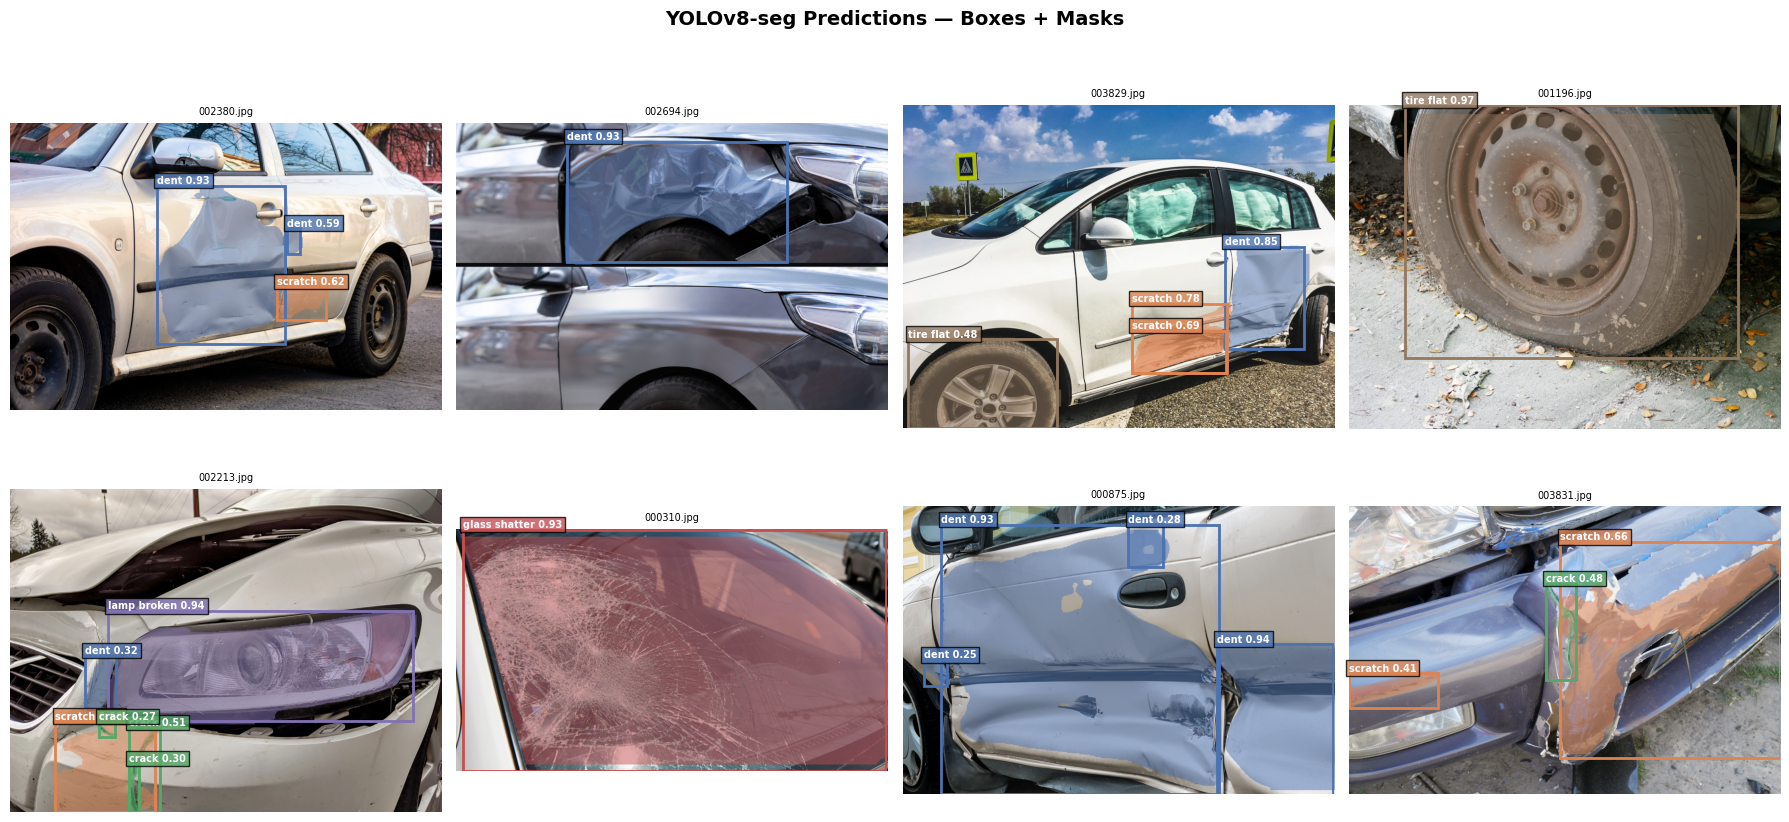


✅ Evaluation complete!


In [15]:


# ── Visualize masks on sample images ────────────────────────────────────


test_img_dir = f'{OUTPUT_BASE}/images/test'
test_images  = os.listdir(test_img_dir)
samples      = random.sample(test_images, 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, fname in zip(axes, samples):
    img_path = os.path.join(test_img_dir, fname)
    result   = model(img_path, verbose=False)[0]
    img      = np.array(Image.open(img_path).convert('RGB'))
    overlay  = img.copy()

    # draw masks
    if result.masks is not None:
        for j, mask in enumerate(result.masks.data):
            cls_id = int(result.boxes.cls[j])
            color  = COLORS[cls_id]
            mask_np = mask.cpu().numpy()

            # resize mask to image size
            mask_resized = np.array(Image.fromarray(mask_np).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST))

            # apply colored mask
            overlay[mask_resized > 0.5] = (
                0.5 * overlay[mask_resized > 0.5] +
                0.5 * np.array(color)
            ).astype(np.uint8)

    # draw boxes and labels on top
    ax.imshow(overlay)
    if result.boxes is not None:
        for j, box in enumerate(result.boxes):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            color  = [c/255 for c in COLORS[cls_id]]
            rect   = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{CLASSES[cls_id]} {conf:.2f}",
                    color='white', fontsize=7, fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.8, pad=2))

    ax.set_title(fname, fontsize=7)
    ax.axis('off')

plt.suptitle('YOLOv8-seg Predictions — Boxes + Masks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seg_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Evaluation complete!")